In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/df_complet.csv', sep=';', dtype={'CODE_INSEE': str})

display(df)

/tmp/ipykernel_42292/660876150.py:6: DtypeWarning: Columns (0: Code_INSEE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/df_complet.csv', sep=';', dtype={'CODE_INSEE': str})


,Année,Code_INSEE,Résultat,Femmes,Hommes,Agriculteurs,Artisans,Cadres,Intermédiaires,Employés,...,55-64 ans,65-79 ans,80 ans et +,Mariés,Pacsés,Concubinage,Veufs,Divorcés,Célibataires,Population_active
0,2022,01001,droite,328.874286,363.234286,4.908571,39.268571,73.628571,103.080000,107.988571,...,131.000000,128.000000,44.000000,357.000000,55.000000,115.000000,41.000000,22.000000,107.000000,697.000000
1,2022,01002,gauche,89.345455,109.200000,24.818182,4.963636,19.854545,29.781818,19.854545,...,26.000000,32.000000,18.000000,103.000000,24.000000,21.000000,7.000000,16.000000,45.000000,216.000000
2,2022,01004,droite,6660.206201,5934.302494,16.032418,392.232934,983.205730,1944.301069,2236.854970,...,1818.260858,2040.179086,769.098809,5158.413539,734.930321,1253.876355,853.759327,1078.958883,3481.713288,12594.508695
3,2022,01005,droite,798.103479,744.261328,5.636287,101.904045,135.089600,237.649785,328.753738,...,268.831175,239.134291,86.467498,758.673406,121.875706,220.625154,71.867895,70.087419,311.225980,1554.355560
4,2022,01006,droite,41.454545,57.000000,0.000000,0.000000,0.000000,10.363636,15.545455,...,24.000000,26.000000,6.000000,51.000000,9.000000,11.000000,3.000000,10.000000,20.000000,104.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34710,2022,95676,droite,210.196629,169.755939,0.000000,20.221523,35.135483,94.824571,79.137430,...,63.580874,65.305688,17.417783,182.283388,17.842724,60.270014,19.626753,23.755654,80.845508,384.624042
34711,2022,95678,droite,319.247059,359.152941,0.000000,54.870588,114.729412,144.658824,74.823529,...,122.000000,96.000000,50.000000,320.000000,71.000000,90.000000,35.000000,32.000000,152.000000,700.000000
34712,2022,95680,gauche,11144.103286,10452.072763,0.000000,639.813936,882.423154,2590.873430,4525.300632,...,2943.191733,2313.955556,707.841948,9711.794617,254.462856,1615.639951,895.822727,1141.682877,7954.497162,21596.176049
34713,2022,95682,droite,75.428571,75.428571,0.000000,4.714286,23.571429,33.000000,37.714286,...,13.619048,11.523810,9.428571,68.095238,10.476190,24.095238,6.285714,5.238095,33.523810,150.857143


## Transformation en pourcentage

In [266]:
cols_famille = ['Personne seule', 'Homme seul', 'Femme seule', 'Colocation', 'Famille', 
                'Famille monoparentale', 'Couple sans enfant', 'Couple avec enfants']

df[cols_famille] = df[cols_famille].div(df['Population avec enfants'], axis=0) * 100

df = df.rename(columns={col: f'pct_{col}' for col in cols_famille})
df.columns


Index(['Année', 'Code_INSEE', 'Résultat', 'Femmes', 'Hommes', 'Agriculteurs',
       'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers',
       'Retraités', 'Etudiants', 'Inactifs', 'pct_Personne seule',
       'pct_Homme seul', 'pct_Femme seule', 'pct_Colocation', 'pct_Famille',
       'pct_Famille monoparentale', 'pct_Couple sans enfant',
       'pct_Couple avec enfants', 'Population avec enfants', '15-24 ans',
       '25-39 ans', '40-54 ans', '55-64 ans', '65-79 ans', '80 ans et +',
       'Mariés', 'Pacsés', 'Concubinage', 'Veufs', 'Divorcés', 'Célibataires',
       'Population_active'],
      dtype='str')

In [267]:
cols_info = ['Femmes', 'Hommes', 'Agriculteurs',
       'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers',
       'Retraités', 'Etudiants', 'Inactifs', '15-24 ans',
       '25-39 ans', '40-54 ans', '55-64 ans', '65-79 ans', '80 ans et +',
       'Mariés', 'Pacsés', 'Concubinage', 'Veufs', 'Divorcés', 'Célibataires']

df[cols_info] = df[cols_info].div(df['Population_active'], axis=0) * 100

df = df.rename(columns={col: f'pct_{col}' for col in cols_info})
df.columns

Index(['Année', 'Code_INSEE', 'Résultat', 'pct_Femmes', 'pct_Hommes',
       'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires',
       'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants',
       'pct_Inactifs', 'pct_Personne seule', 'pct_Homme seul',
       'pct_Femme seule', 'pct_Colocation', 'pct_Famille',
       'pct_Famille monoparentale', 'pct_Couple sans enfant',
       'pct_Couple avec enfants', 'Population avec enfants', 'pct_15-24 ans',
       'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans', 'pct_65-79 ans',
       'pct_80 ans et +', 'pct_Mariés', 'pct_Pacsés', 'pct_Concubinage',
       'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires', 'Population_active'],
      dtype='str')

## Suppression des petites commune 

In [268]:
df = df[df['Population_active'] > 100]

display(df)

,Année,Code_INSEE,Résultat,pct_Femmes,pct_Hommes,pct_Agriculteurs,pct_Artisans,pct_Cadres,pct_Intermédiaires,pct_Employés,...,pct_55-64 ans,pct_65-79 ans,pct_80 ans et +,pct_Mariés,pct_Pacsés,pct_Concubinage,pct_Veufs,pct_Divorcés,pct_Célibataires,Population_active
0,2022,01001,droite,47.184259,52.113958,0.704243,5.633941,10.563640,14.789096,15.493339,...,18.794835,18.364419,6.312769,51.219512,7.890961,16.499283,5.882353,3.156385,15.351506,697.000000
1,2022,01002,gauche,41.363637,50.555556,11.489899,2.297980,9.191919,13.787879,9.191919,...,12.037037,14.814815,8.333333,47.685185,11.111111,9.722222,3.240741,7.407407,20.833333,216.000000
2,2022,01004,droite,52.881826,47.118174,0.127297,3.114317,7.806622,15.437689,17.760558,...,14.436934,16.198957,6.106620,40.957640,5.835323,9.955739,6.778822,8.566899,27.644693,12594.508695
3,2022,01005,droite,51.346262,47.882309,0.362612,6.556032,8.691036,15.289281,21.150485,...,17.295346,15.384787,5.562916,48.809515,7.840915,14.193995,4.623646,4.509098,20.022831,1554.355560
4,2022,01006,droite,39.860139,54.807692,0.000000,0.000000,0.000000,9.965035,14.947553,...,23.076923,25.000000,5.769231,49.038462,8.653846,10.576923,2.884615,9.615385,19.230769,104.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34710,2022,95676,droite,54.649893,44.135551,0.000000,5.257478,9.135020,24.653834,20.575269,...,16.530655,16.979097,4.528522,47.392614,4.639004,15.669851,5.102841,6.176331,21.019359,384.624042
34711,2022,95678,droite,45.606723,51.307563,0.000000,7.838655,16.389916,20.665546,10.689076,...,17.428571,13.714286,7.142857,45.714286,10.142857,12.857143,5.000000,4.571429,21.714286,700.000000
34712,2022,95680,gauche,51.602206,48.397794,0.000000,2.962626,4.086016,11.996908,20.954176,...,13.628300,10.714654,3.277626,44.969973,1.178277,7.481139,4.148062,5.286505,36.832896,21596.176049
34713,2022,95682,droite,50.000000,50.000000,0.000000,3.125000,15.625000,21.875000,25.000000,...,9.027778,7.638889,6.250000,45.138889,6.944444,15.972222,4.166666,3.472222,22.222223,150.857143


## Vérification des valeurs 

In [269]:
metier = ['pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires', 'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants', 'pct_Inactifs']
age = ['pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans', 'pct_65-79 ans', 'pct_80 ans et +']
status = ['pct_Mariés', 'pct_Pacsés', 'pct_Concubinage', 'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires',]
menage = ['pct_Personne seule', 'pct_Homme seul', 'pct_Femme seule', 'pct_Colocation', 'pct_Famille', 'pct_Famille monoparentale', 'pct_Couple sans enfant', 'pct_Couple avec enfants']

In [270]:
df['sum_metier'] = df[metier].sum(axis=1)
df[df['sum_metier'] <90][['Code_INSEE', 'Population_active', 'sum_metier']]
# df = df[df['sum_metier'] <= 104]

,Code_INSEE,Population_active,sum_metier
276,01329,134.000000,87.966418
519,02136,105.703125,84.263323
527,02144,114.000000,84.210526
599,02219,157.206884,89.057015
633,02254,104.832000,89.174938
...,...,...,...
33663,88504,132.000000,84.946236
33783,89101,416.605744,88.484530
33836,89165,107.000000,87.706686
33951,89296,105.691057,87.606839


In [271]:
df['sum_age'] = df[age].sum(axis=1)
df[df['sum_age'] < 90][['Population_active', 'sum_age']]
# df = df[df['sum_age'] <= 104]

,Population_active,sum_age
11,140.000000,89.855073
40,262.975420,84.047299
234,119.000000,88.888889
365,114.625000,88.888890
559,104.866667,88.128408
...,...,...
33852,129.000000,87.500001
34138,127.111111,88.379705
34546,131.555556,88.175675
34615,261.112132,89.927426


In [272]:
df['sum_status'] = df[status].sum(axis=1)
df[df['sum_status'] < 90][['Population_active', 'sum_status']]
# df = df[df['sum_status'] <= 104]

,Population_active,sum_status
11,140.000000,89.855073
40,262.975420,84.047299
234,119.000000,88.888889
365,114.625000,88.888888
559,104.866667,88.128407
...,...,...
33852,129.000000,87.500002
34138,127.111111,88.379705
34546,131.555556,88.175675
34615,261.112132,89.927426


In [273]:
menage_top = ['pct_Colocation', 'pct_Famille', 'pct_Personne seule']
df['sum_menage_top'] = df[menage_top].sum(axis=1)
df[df['sum_menage_top'] < 95][['Population_active', 'sum_menage_top']]
# df = df[df['sum_menage_top'] <= 104]

,Population_active,sum_menage_top


In [274]:
# df[df['RATE_FAMILY_SINGLE_PARENT'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_SINGLE_PARENT']]
# df[df['RATE_FAMILY_CHILDREN'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDREN']]
# df[df['RATE_FAMILY_CHILDLESS'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDLESS']]
# df[df['RATE_ONE_WOMAN'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_ONE_WOMAN']]


### Boxplot

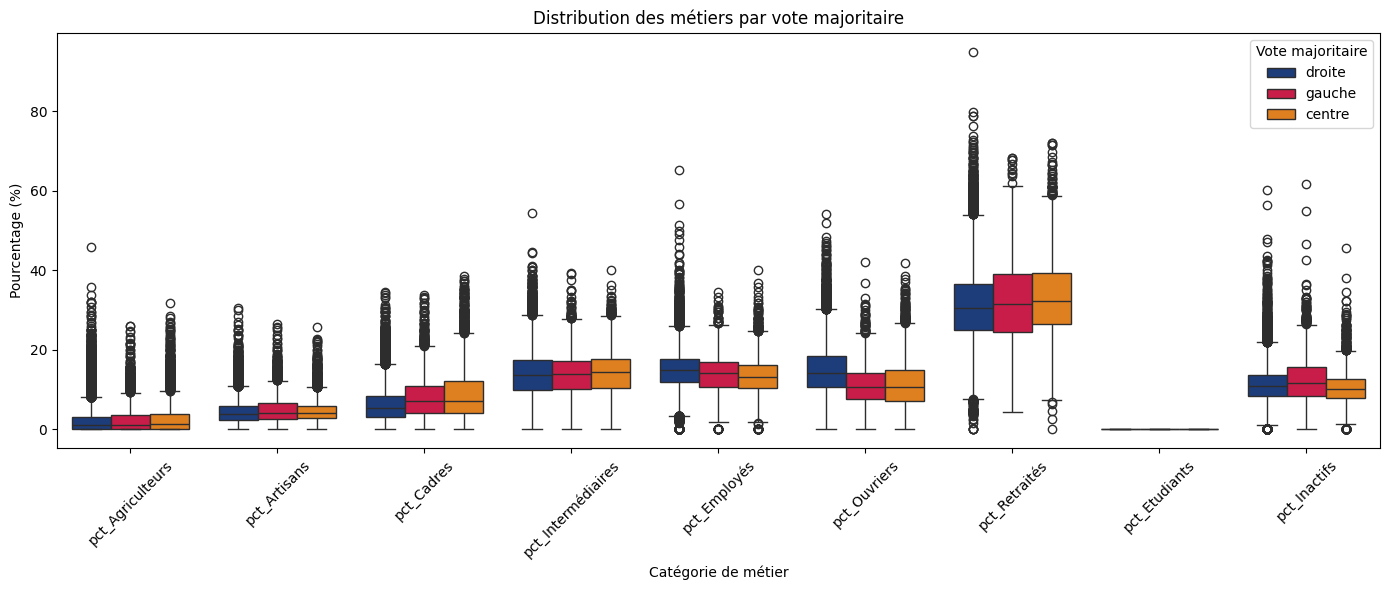

In [275]:
# Transformer le dataframe en format long pour seaborn
df_metier = df[metier + ['Résultat']].melt(
    id_vars='Résultat',
    value_vars=metier,
    var_name='metier',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_metier,
    x='metier',
    y='pourcentage',
    hue='Résultat',
    palette={'gauche': '#E4003A', 'centre': '#FF8000','droite': '#0D378A'}
)

plt.title('Distribution des métiers par vote majoritaire')
plt.xlabel('Catégorie de métier')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

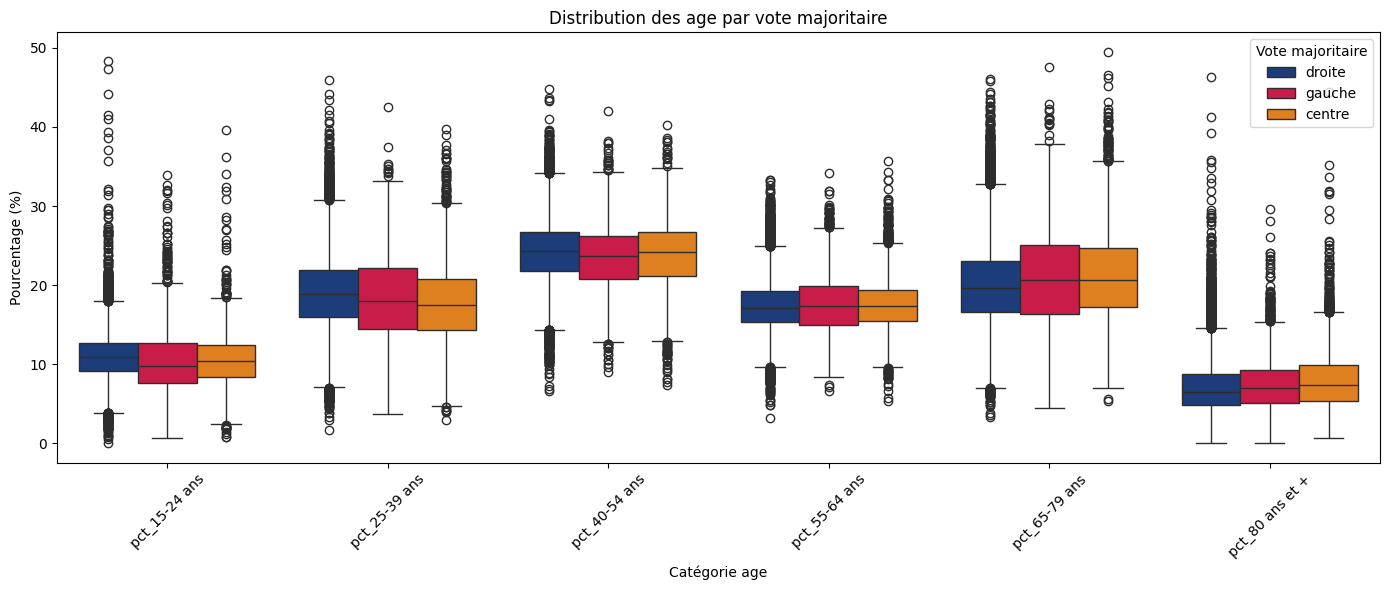

In [276]:
# Transformer le dataframe en format long pour seaborn
df_age = df[age + ['Résultat']].melt(
    id_vars='Résultat',
    value_vars=age,
    var_name='age',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_age,
    x='age',
    y='pourcentage',
    hue='Résultat',
    palette={'gauche': '#E4003A', 'centre': '#FF8000','droite': '#0D378A'}
)

plt.title('Distribution des age par vote majoritaire')
plt.xlabel('Catégorie age')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

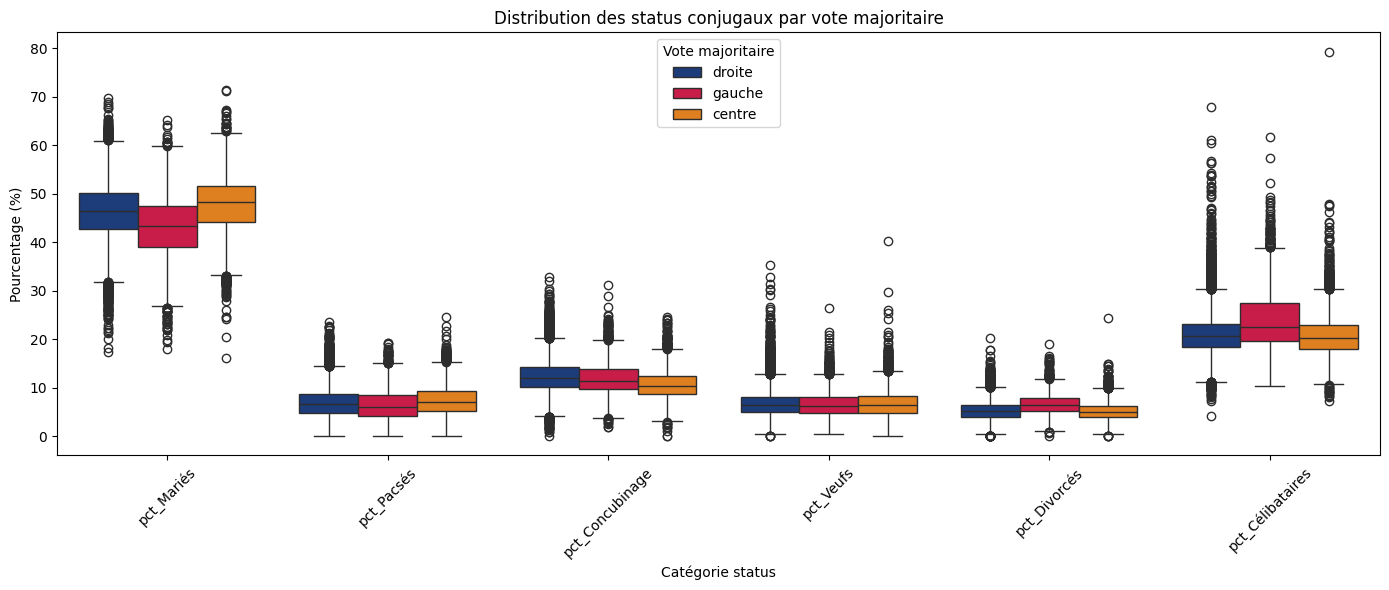

In [277]:
# Transformer le dataframe en format long pour seaborn
df_status = df[status + ['Résultat']].melt(
    id_vars='Résultat',
    value_vars=status,
    var_name='status',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_status,
    x='status',
    y='pourcentage',
    hue='Résultat',
    palette={'gauche': '#E4003A', 'centre': '#FF8000','droite': '#0D378A'}
)

plt.title('Distribution des status conjugaux par vote majoritaire')
plt.xlabel('Catégorie status')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

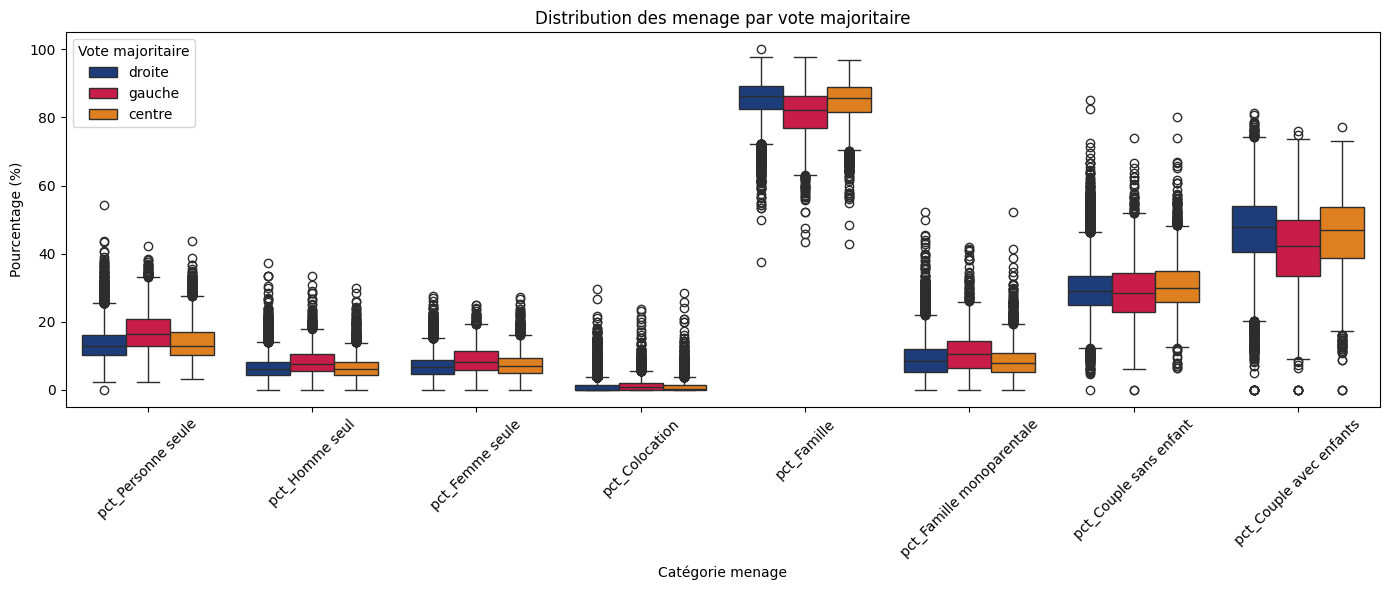

In [278]:
# Transformer le dataframe en format long pour seaborn
df_menage = df[menage + ['Résultat']].melt(
    id_vars='Résultat',
    value_vars=menage,
    var_name='menage',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_menage,
    x='menage',
    y='pourcentage',
    hue='Résultat',
    palette={'gauche': '#E4003A', 'centre': '#FF8000','droite': '#0D378A'}
)

plt.title('Distribution des menage par vote majoritaire')
plt.xlabel('Catégorie menage')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

### Corrélation 

In [279]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix[corr_matrix.abs() > 0.5].stack().dropna()

pct_Femmes      pct_Femmes         1.000000
                pct_Hommes        -0.849346
                pct_Femme seule    0.524150
pct_Hommes      pct_Femmes        -0.849346
                pct_Hommes         1.000000
                                     ...   
sum_age         sum_age            1.000000
                sum_status         1.000000
sum_status      sum_age            1.000000
                sum_status         1.000000
sum_menage_top  sum_menage_top     1.000000
Length: 130, dtype: float64

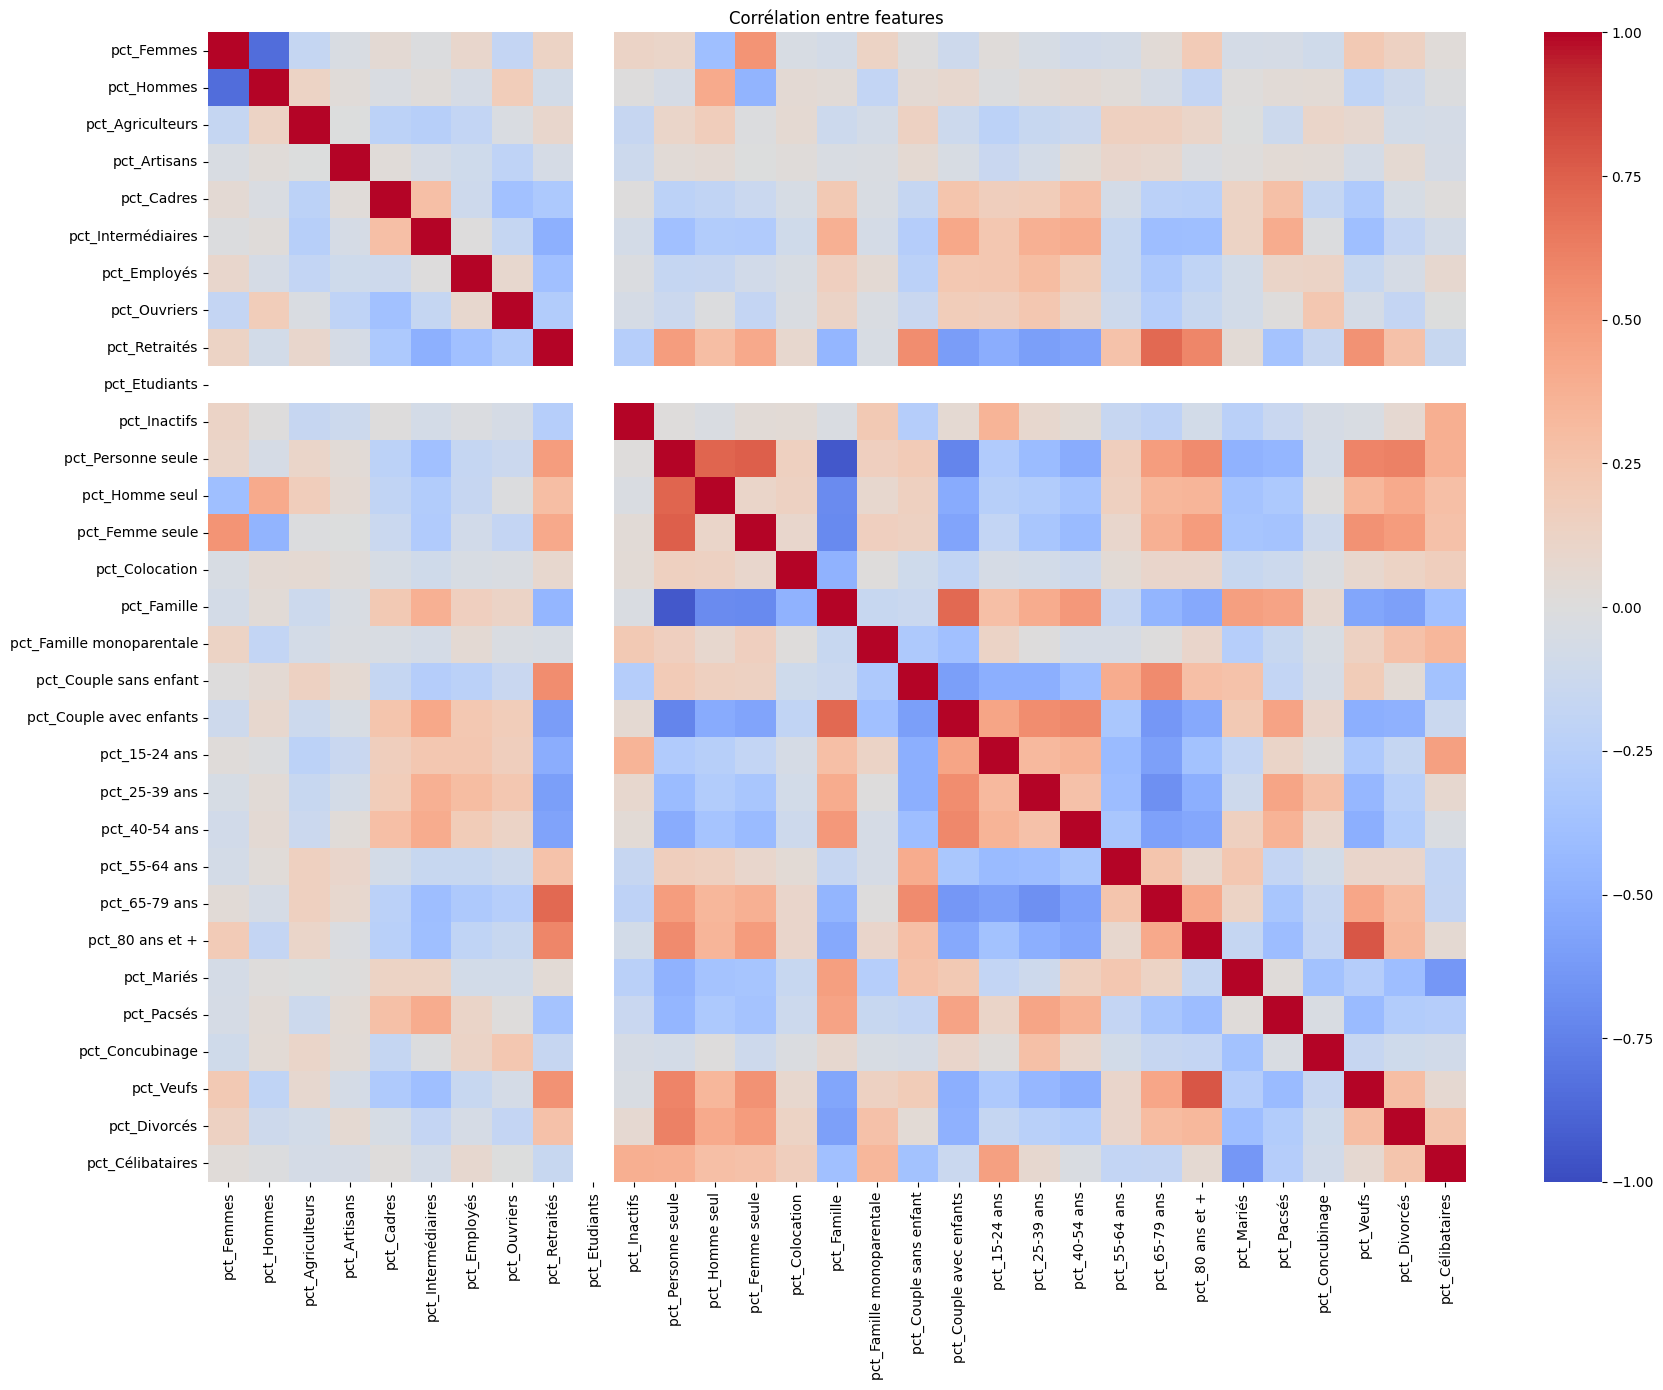

In [280]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes features uniquement (sans colonnes elections et cible)
features = ['pct_Femmes', 'pct_Hommes',
       'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires',
       'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants',
       'pct_Inactifs', 'pct_Personne seule', 'pct_Homme seul',
       'pct_Femme seule', 'pct_Colocation', 'pct_Famille',
       'pct_Famille monoparentale', 'pct_Couple sans enfant',
       'pct_Couple avec enfants',
       'pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans',
       'pct_65-79 ans', 'pct_80 ans et +', 'pct_Mariés', 'pct_Pacsés',
       'pct_Concubinage', 'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires',
]

corr_matrix = df[features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Corrélation entre features')
plt.tight_layout()
plt.show()

In [281]:
# Paires de features avec corrélation > 0.8 ou < -0.8
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[
    ((corr_pairs > 0.7) | (corr_pairs < -0.7)) & (corr_pairs != 1.0)
].sort_values(ascending=False)

# Supprimer les doublons (A-B et B-A)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

print(corr_pairs)

pct_80 ans et +          pct_Veufs                  0.783769
pct_Veufs                pct_80 ans et +            0.783769
pct_Personne seule       pct_Femme seule            0.757084
pct_Femme seule          pct_Personne seule         0.757084
pct_Homme seul           pct_Personne seule         0.727881
pct_Personne seule       pct_Homme seul             0.727881
pct_Couple avec enfants  pct_Famille                0.717195
pct_Famille              pct_Couple avec enfants    0.717195
pct_65-79 ans            pct_Retraités              0.714971
pct_Retraités            pct_65-79 ans              0.714971
pct_Femme seule          pct_Famille               -0.704345
pct_Famille              pct_Femme seule           -0.704345
pct_Couple avec enfants  pct_Personne seule        -0.733227
pct_Personne seule       pct_Couple avec enfants   -0.733227
pct_Hommes               pct_Femmes                -0.849346
pct_Femmes               pct_Hommes                -0.849346
pct_Personne seule      

In [282]:
df[features].describe().loc[['mean', 'std', 'max']].T.sort_values('max')

,mean,std,max
pct_Etudiants,0.000000,0.000000,0.000000
pct_Divorcés,5.419876,1.960800,24.277117
pct_Pacsés,6.977953,3.016935,24.489796
pct_Femme seule,7.259283,3.527434,27.725465
pct_Colocation,1.122396,1.946687,29.545455
pct_Artisans,4.407250,3.041312,30.434783
pct_Concubinage,12.035430,3.299169,32.765957
pct_55-64 ans,17.445503,3.217129,35.691466
pct_Homme seul,6.758651,3.360830,37.154490
pct_Cadres,6.674218,5.008296,38.595895


In [283]:
def supprimer_redondantes(corr_matrix, seuil=0.7):
    a_supprimer = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= seuil:
                # Garder la première, supprimer la deuxième
                a_supprimer.add(corr_matrix.columns[j])
    return list(a_supprimer)

cols_a_supprimer = supprimer_redondantes(corr_matrix, seuil=0.7)
print(f"Colonnes supprimées : {cols_a_supprimer}")
df = df.drop(columns=cols_a_supprimer)

Colonnes supprimées : ['pct_Hommes', 'pct_Famille', 'pct_Homme seul', 'pct_Veufs', 'pct_65-79 ans', 'pct_Couple avec enfants', 'pct_Femme seule']


In [284]:
colonnes_a_supprimer = [
    'pct_Etudiants', 'sum_metier', 'sum_age', 'sum_status', 'sum_menage_top'
]

df = df.drop(columns=colonnes_a_supprimer)

print(f"Colonnes restantes : {df.shape[1]}")
print(df.columns.tolist())

Colonnes restantes : 28
['Année', 'Code_INSEE', 'Résultat', 'pct_Femmes', 'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires', 'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Inactifs', 'pct_Personne seule', 'pct_Colocation', 'pct_Famille monoparentale', 'pct_Couple sans enfant', 'Population avec enfants', 'pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans', 'pct_80 ans et +', 'pct_Mariés', 'pct_Pacsés', 'pct_Concubinage', 'pct_Divorcés', 'pct_Célibataires', 'Population_active']


In [285]:
print(df['Résultat'].value_counts())

Résultat
droite    23386
centre     4240
gauche     2812
Name: count, dtype: int64


In [286]:
# def categorie_commune(habitants):
#     if habitants < 2000:
#         return "rurale"
#     elif habitants < 10000:
#         return "petite_commune"
#     elif habitants < 50000:
#         return "ville_moyenne"
#     elif habitants < 100000:
#         return "grande_ville"
#     else:
#         return "tres_grande_ville"

# df['categorie_commune'] = df['Population_active'].apply(categorie_commune)

# # Vérification
# print(df['categorie_commune'].value_counts())

In [287]:
# df = pd.get_dummies(df, columns=['categorie_commune'], prefix='commune')

# # Vérification
# print(df.columns.tolist())

              precision    recall  f1-score   support

      centre       0.52      0.27      0.35       848
      droite       0.83      0.93      0.87      4678
      gauche       0.44      0.30      0.35       562

    accuracy                           0.78      6088
   macro avg       0.59      0.50      0.53      6088
weighted avg       0.75      0.78      0.75      6088



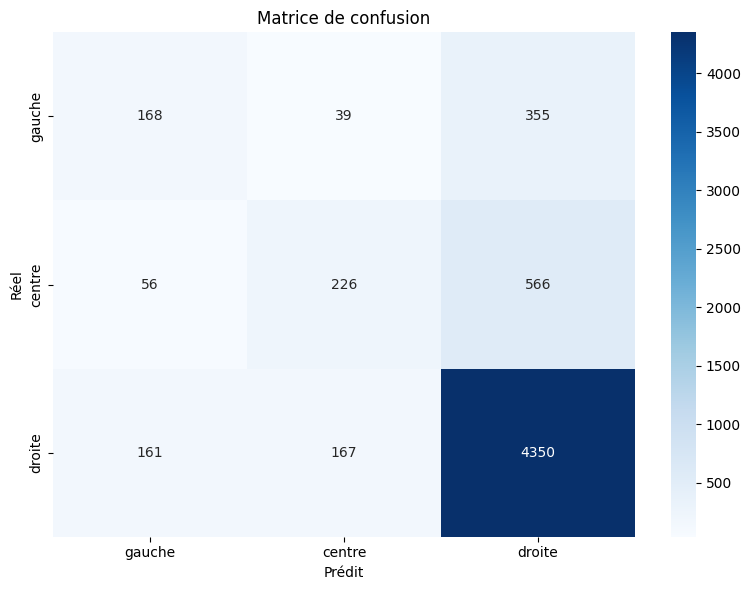

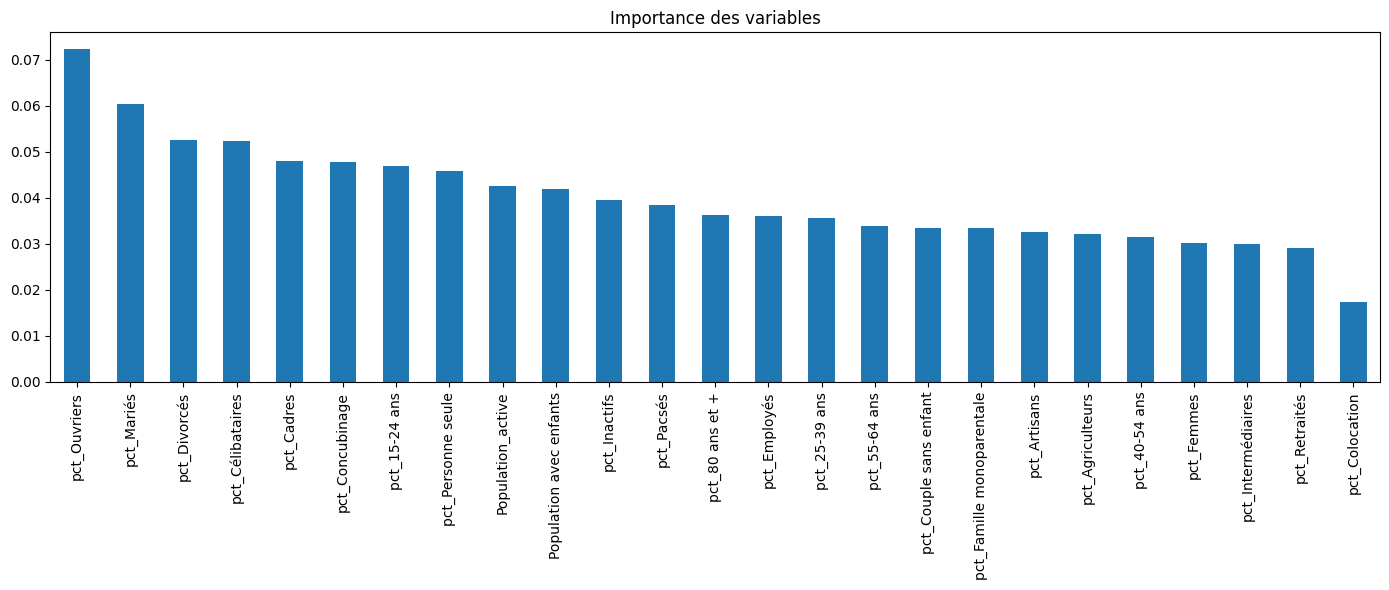


Features peu utiles (importance < 1%) :
Series([], dtype: float64)


In [288]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

features = [col for col in df.columns if col not in ['Année', 'Code_INSEE', 'Résultat']]

X = df[features]
y = df['Résultat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['gauche', 'centre', 'droite'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['gauche', 'centre', 'droite'],
            yticklabels=['gauche', 'centre', 'droite'],
            cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(14, 6))
importances.plot(kind='bar')
plt.title('Importance des variables')
plt.tight_layout()
plt.show()

# Features proches de 0
print("\nFeatures peu utiles (importance < 1%) :")
print(importances[importances < 0.01])

In [289]:
df.to_csv('../data/df_model.csv', index=False, sep=';', encoding='utf-8')